# Import

In [1]:
import math
import os
import sys
from pathlib import Path

# plots.ipynb lives in ml/evaluation/, so climb 2 levels to reach the project root
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

import matplotlib.pyplot as plt
import mlflow
import pandas as pd
from mlflow.tracking import MlflowClient
from sklearn.metrics import auc, precision_recall_curve, roc_curve

from config import settings
from ml.evaluation.metrics import compute_metrics

mlflow.set_tracking_uri(settings.MLFLOW_TRACKING_URI)

/home/simone/credit-default-pipeline/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Baseline
Logistic Regression model

## Training metrics

In [2]:
# Locate the most recent cross-validation parent run for the baseline experiment
experiment = mlflow.get_experiment_by_name("baseline")

parent_runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.mlflow.runName LIKE 'cross_validation%'",
    order_by=["start_time DESC"],
    max_results=1,
)
parent_run_id = parent_runs.iloc[0]["run_id"]

# Fetch the 5 nested fold runs under that parent
fold_runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string=f"tags.mlflow.parentRunId = '{parent_run_id}'",
    order_by=["tags.mlflow.runName ASC"],
)

# Download and load each fold's validation predictions CSV
fold_predictions = []
for _, run in fold_runs.iterrows():
    local_path = mlflow.artifacts.download_artifacts(
        run_id=run["run_id"], artifact_path="predictions"
    )
    csv_files = [f for f in os.listdir(local_path) if f.endswith(".csv")]
    fold_df = pd.read_csv(f"{local_path}/{csv_files[0]}")
    fold_predictions.append(fold_df)

In [3]:
# Aggregated metrics: concatenate every fold's predictions into a single curve
all_predictions = pd.concat(fold_predictions, ignore_index=True)

fpr_agg, tpr_agg, roc_thresholds_agg = roc_curve(
    all_predictions["y_true"], all_predictions["y_pred_proba"]
)
precision_agg, recall_agg, pr_thresholds_agg = precision_recall_curve(
    all_predictions["y_true"], all_predictions["y_pred_proba"]
)

auc_roc_agg = auc(fpr_agg, tpr_agg)
auc_pr_agg = auc(recall_agg, precision_agg)

print(f"Aggregated AUC-ROC: {auc_roc_agg:.4f}")
print(f"Aggregated AUC-PR:  {auc_pr_agg:.4f}")

Aggregated AUC-ROC: 0.9650
Aggregated AUC-PR:  0.8699


In [4]:
# Per-fold metrics: same computation, kept separate per fold
fold_curves = []
for i, fold_df in enumerate(fold_predictions, start=1):
    fpr, tpr, _ = roc_curve(fold_df["y_true"], fold_df["y_pred_proba"])
    precision, recall, _ = precision_recall_curve(
        fold_df["y_true"], fold_df["y_pred_proba"]
    )
    fold_curves.append(
        {
            "fold": i,
            "fpr": fpr,
            "tpr": tpr,
            "precision": precision,
            "recall": recall,
            "auc_roc": auc(fpr, tpr),
            "auc_pr": auc(recall, precision),
        }
    )
    print(
        f"Fold {i}: AUC-ROC={fold_curves[-1]['auc_roc']:.4f}  "
        "AUC-PR={fold_curves[-1]['auc_pr']:.4f}"
    )

Fold 1: AUC-ROC=0.9106  AUC-PR={fold_curves[-1]['auc_pr']:.4f}
Fold 2: AUC-ROC=0.9902  AUC-PR={fold_curves[-1]['auc_pr']:.4f}
Fold 3: AUC-ROC=0.9886  AUC-PR={fold_curves[-1]['auc_pr']:.4f}
Fold 4: AUC-ROC=0.9858  AUC-PR={fold_curves[-1]['auc_pr']:.4f}
Fold 5: AUC-ROC=0.9837  AUC-PR={fold_curves[-1]['auc_pr']:.4f}


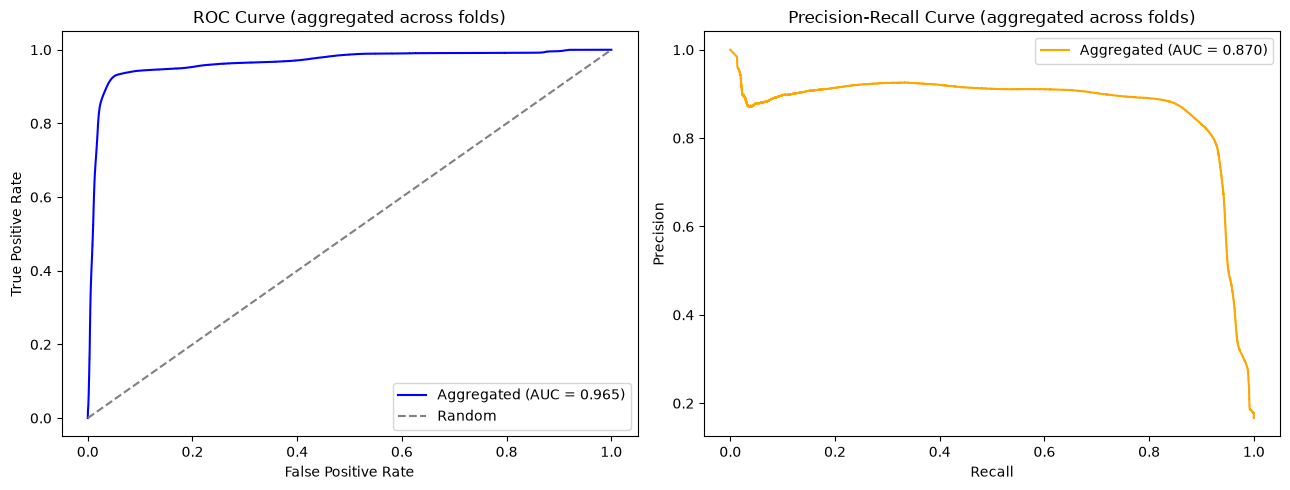

In [5]:
# Plot: aggregated ROC and Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    fpr_agg, tpr_agg, label=f"Aggregated (AUC = {auc_roc_agg:.3f})", color="blue"
)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (aggregated across folds)")
axes[0].legend()

axes[1].plot(
    recall_agg,
    precision_agg,
    label=f"Aggregated (AUC = {auc_pr_agg:.3f})",
    color="orange",
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (aggregated across folds)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
# Threshold selection via F-beta (beta=2): weights recall higher than precision,
# consistent with the higher cost of a missed insolvency (false negative) vs a
# false alarm (false positive). Plain F1 was considered but rejected, since it
# weights precision and recall equally and does not reflect this cost asymmetry.
beta = 2

precision_valid = precision_agg[:-1]
recall_valid = recall_agg[:-1]

fbeta_scores = (
    (1 + beta**2)
    * (precision_valid * recall_valid)
    / (beta**2 * precision_valid + recall_valid + 1e-10)
)

best_idx = fbeta_scores.argmax()
best_threshold = pr_thresholds_agg[best_idx]

print(f"Best threshold (maximizing F{beta}): {best_threshold:.4f}")
print(
    f"At that threshold: precision={precision_valid[best_idx]:.4f}, "
    f"recall={recall_valid[best_idx]:.4f}, F{beta}={fbeta_scores[best_idx]:.4f}"
)

Best threshold (maximizing F2): 0.5047
At that threshold: precision=0.7855, recall=0.9283, F2=0.8957


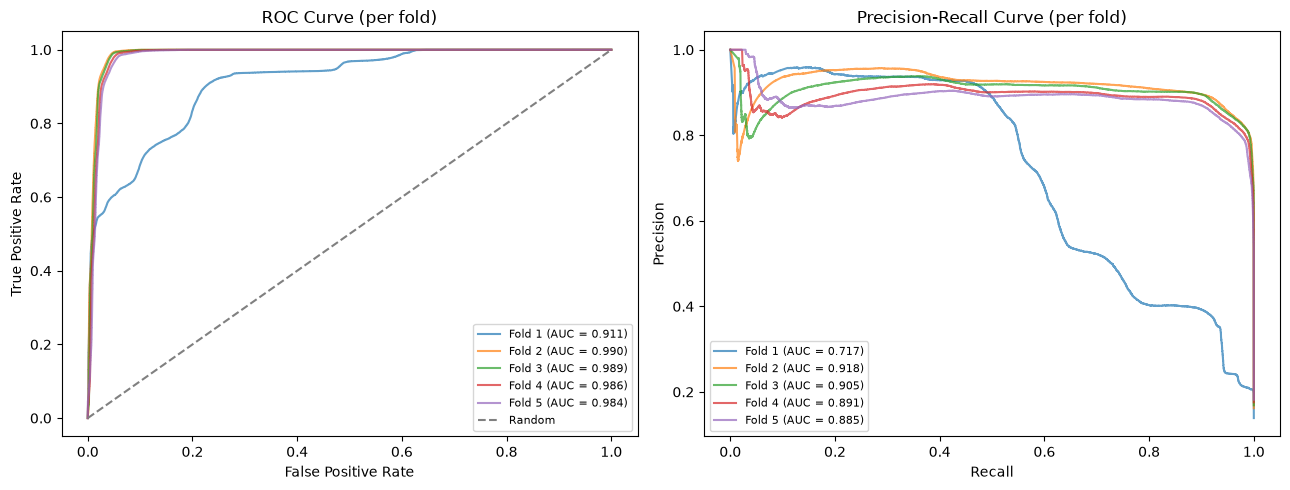

In [7]:
# Plot: per-fold ROC and Precision-Recall curves, overlaid
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for fc in fold_curves:
    axes[0].plot(
        fc["fpr"],
        fc["tpr"],
        alpha=0.7,
        label=f"Fold {fc['fold']} (AUC = {fc['auc_roc']:.3f})",
    )
    axes[1].plot(
        fc["recall"],
        fc["precision"],
        alpha=0.7,
        label=f"Fold {fc['fold']} (AUC = {fc['auc_pr']:.3f})",
    )

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (per fold)")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (per fold)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [8]:
train_metrics_at_threshold = compute_metrics(
    all_predictions["y_true"],
    all_predictions["y_pred_proba"].to_numpy(),
    threshold=best_threshold,
)
train_metrics_at_threshold

{'auc_roc': 0.9650373395305236,
 'auc_pr': 0.8698246248895382,
 'precision': 0.7854676876129404,
 'recall': 0.9282865215223534,
 'f1': 0.8509260705131378,
 'true_positives': 111710,
 'false_positives': 30511,
 'true_negatives': 572181,
 'false_negatives': 8630}

## Test metrics

In [9]:
# Locate the most recent final_model run for the baseline experiment
final_runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.mlflow.runName LIKE 'final_model%'",
    order_by=["start_time DESC"],
    max_results=1,
)
final_run_id = final_runs.iloc[0]["run_id"]

# Download and load the test set predictions CSV
local_path = mlflow.artifacts.download_artifacts(
    run_id=final_run_id, artifact_path="predictions"
)
csv_files = [f for f in os.listdir(local_path) if f.endswith(".csv")]
test_predictions = pd.read_csv(f"{local_path}/{csv_files[0]}")

In [10]:
# Test set metrics: same computation as the aggregated training curves, on the
# untouched holdout test set
fpr_test, tpr_test, roc_thresholds_test = roc_curve(
    test_predictions["y_true"], test_predictions["y_pred_proba"]
)
precision_test, recall_test, pr_thresholds_test = precision_recall_curve(
    test_predictions["y_true"], test_predictions["y_pred_proba"]
)

auc_roc_test = auc(fpr_test, tpr_test)
auc_pr_test = auc(recall_test, precision_test)

print(f"Test AUC-ROC: {auc_roc_test:.4f}")
print(f"Test AUC-PR:  {auc_pr_test:.4f}")

Test AUC-ROC: 0.9821
Test AUC-PR:  0.8828


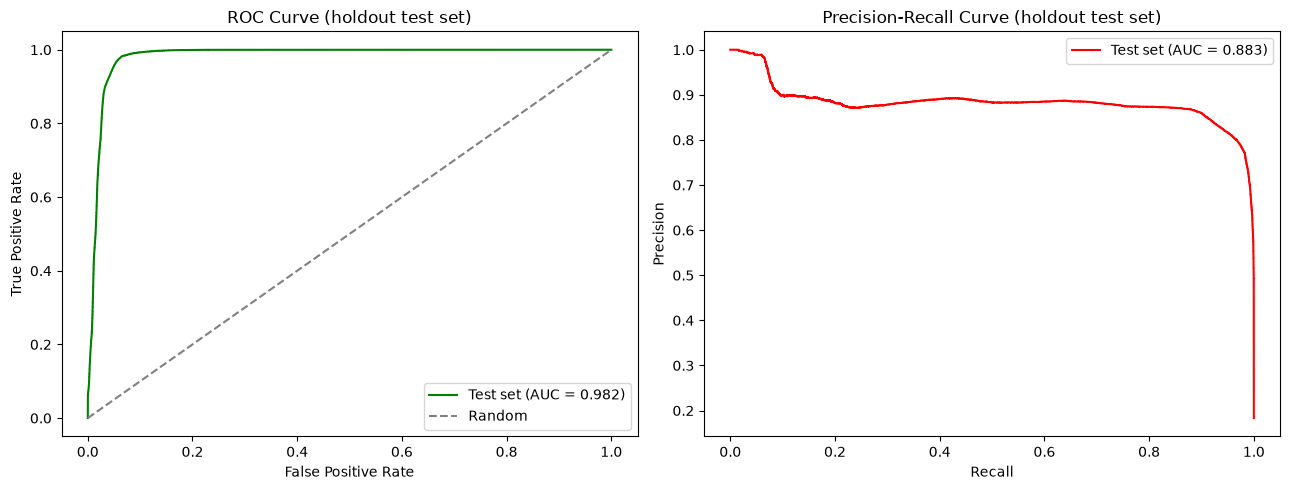

In [11]:
# Plot: ROC and Precision-Recall curves on the holdout test set
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    fpr_test, tpr_test, label=f"Test set (AUC = {auc_roc_test:.3f})", color="green"
)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (holdout test set)")
axes[0].legend()

axes[1].plot(
    recall_test,
    precision_test,
    label=f"Test set (AUC = {auc_pr_test:.3f})",
    color="red",
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (holdout test set)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
# Evaluate the F2-optimal threshold (chosen on validation folds above) on the
# untouched test set, confirming it was not tuned by looking at test data

test_metrics_at_threshold = compute_metrics(
    test_predictions["y_true"],
    test_predictions["y_pred_proba"].to_numpy(),
    threshold=best_threshold,
)
test_metrics_at_threshold

{'auc_roc': 0.9820986042698084,
 'auc_pr': 0.8827769842577157,
 'precision': 0.7831984248523299,
 'recall': 0.9767188068388505,
 'f1': 0.8693188716661945,
 'true_positives': 21480,
 'false_positives': 5946,
 'true_negatives': 92062,
 'false_negatives': 512}

In [13]:
# These lines log optimal metrics on mlflow, therefore they are commented out
# to ensure that they do not execute every time the entire notebook is run.
# with mlflow.start_run(run_id=final_run_id):
#   mlflow.log_param("selected_threshold", best_threshold)
#   mlflow.log_metrics({f"tuned_{k}": v for k, v in test_metrics_at_threshold.items()})

# MLP
PyTorch Multi-Layer Perceptron model

## Training metrics

In [14]:
mlp_experiment = mlflow.get_experiment_by_name("mlp")

mlp_parent_runs = mlflow.search_runs(
    experiment_ids=[mlp_experiment.experiment_id],
    filter_string="tags.mlflow.runName LIKE 'cross_validation%'",
    order_by=["start_time DESC"],
    max_results=1,
)
mlp_parent_run_id = mlp_parent_runs.iloc[0]["run_id"]

# Fetch the nested fold runs under that parent
mlp_fold_runs = mlflow.search_runs(
    experiment_ids=[mlp_experiment.experiment_id],
    filter_string=f"tags.mlflow.parentRunId = '{mlp_parent_run_id}'",
    order_by=["tags.mlflow.runName ASC"],
)

# Download and load each fold's validation predictions CSV
mlp_fold_predictions = []
for _, run in mlp_fold_runs.iterrows():
    local_path = mlflow.artifacts.download_artifacts(
        run_id=run["run_id"], artifact_path="predictions"
    )
    csv_files = [f for f in os.listdir(local_path) if f.endswith(".csv")]
    fold_df = pd.read_csv(f"{local_path}/{csv_files[0]}")
    mlp_fold_predictions.append(fold_df)

### Loss per epoch (train vs validation)

In [15]:
client = MlflowClient()

mlp_loss_histories = []
for _, run in mlp_fold_runs.iterrows():
    run_id = run["run_id"]

    train_loss_history = client.get_metric_history(run_id, "train_loss")
    val_loss_history = client.get_metric_history(run_id, "val_loss")

    mlp_loss_histories.append(
        {
            "run_name": run["tags.mlflow.runName"],
            "train_epochs": [m.step for m in train_loss_history],
            "train_loss": [m.value for m in train_loss_history],
            "val_epochs": [m.step for m in val_loss_history],
            "val_loss": [m.value for m in val_loss_history],
        }
    )

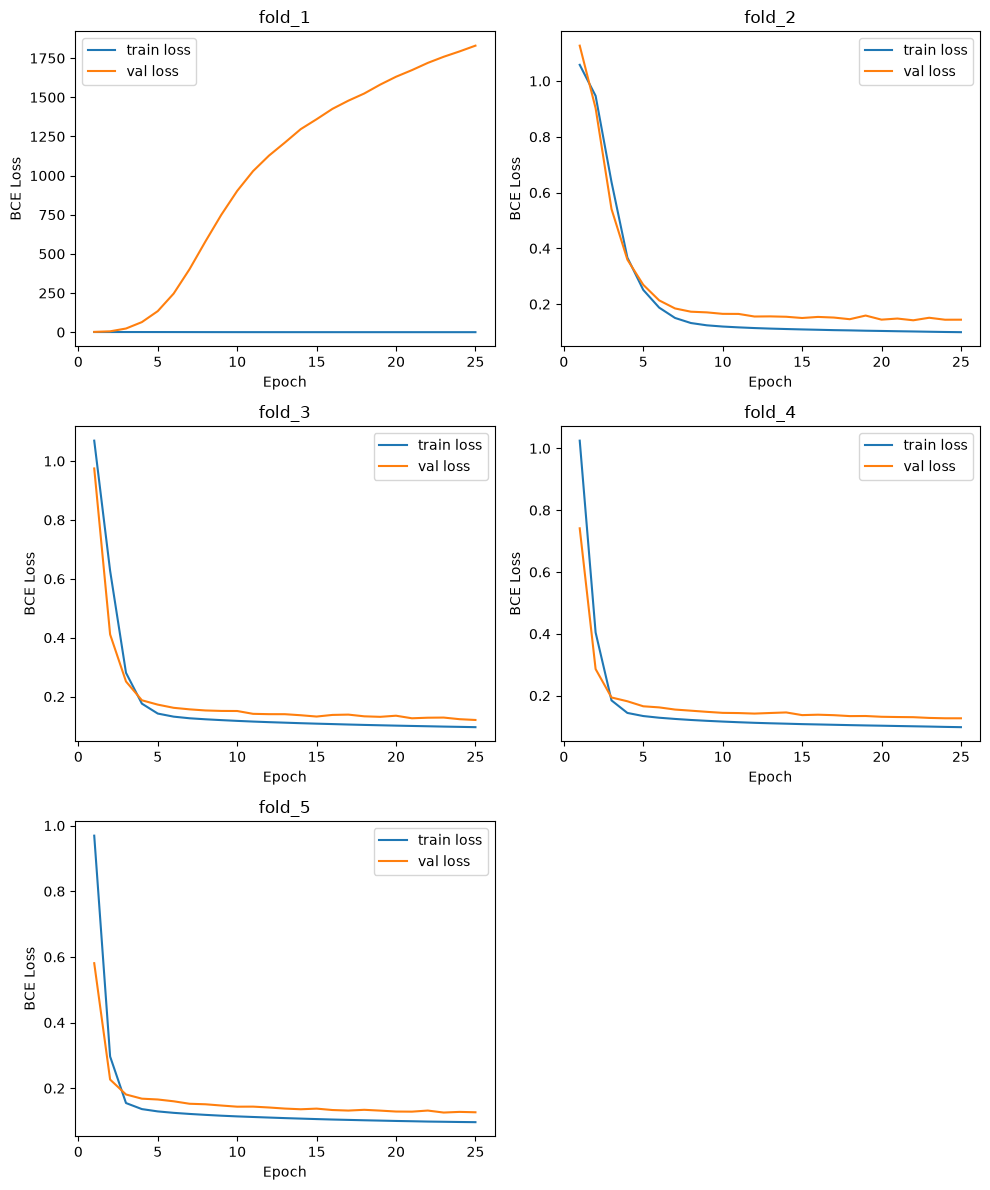

In [16]:
n_folds = len(mlp_loss_histories)
n_cols = 2
n_rows = math.ceil(n_folds / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

if n_folds == 1:
    axes = [axes]

for ax, history in zip(axes, mlp_loss_histories):
    ax.plot(history["train_epochs"], history["train_loss"], label="train loss")
    if history["val_loss"]:
        ax.plot(history["val_epochs"], history["val_loss"], label="val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")
    ax.set_title(history["run_name"])
    ax.legend()

for ax in axes[len(mlp_loss_histories) :]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [17]:
mlp_all_predictions = pd.concat(mlp_fold_predictions, ignore_index=True)

mlp_fpr_agg, mlp_tpr_agg, mlp_roc_thresholds_agg = roc_curve(
    mlp_all_predictions["y_true"], mlp_all_predictions["y_pred_proba"]
)
mlp_precision_agg, mlp_recall_agg, mlp_pr_thresholds_agg = precision_recall_curve(
    mlp_all_predictions["y_true"], mlp_all_predictions["y_pred_proba"]
)

mlp_auc_roc_agg = auc(mlp_fpr_agg, mlp_tpr_agg)
mlp_auc_pr_agg = auc(mlp_recall_agg, mlp_precision_agg)

print(f"Aggregated AUC-ROC: {mlp_auc_roc_agg:.4f}")
print(f"Aggregated AUC-PR:  {mlp_auc_pr_agg:.4f}")

Aggregated AUC-ROC: 0.9367
Aggregated AUC-PR:  0.9075


In [18]:
# Per-fold metrics: same computation, kept separate per fold
mlp_fold_curves = []
for i, fold_df in enumerate(mlp_fold_predictions, start=1):
    fpr, tpr, _ = roc_curve(fold_df["y_true"], fold_df["y_pred_proba"])
    precision, recall, _ = precision_recall_curve(
        fold_df["y_true"], fold_df["y_pred_proba"]
    )
    mlp_fold_curves.append(
        {
            "fold": i,
            "fpr": fpr,
            "tpr": tpr,
            "precision": precision,
            "recall": recall,
            "auc_roc": auc(fpr, tpr),
            "auc_pr": auc(recall, precision),
        }
    )
    print(
        f"Fold {i}: AUC-ROC={mlp_fold_curves[-1]['auc_roc']:.4f}  "
        f"AUC-PR={mlp_fold_curves[-1]['auc_pr']:.4f}"
    )

Fold 1: AUC-ROC=0.6588  AUC-PR=0.5723
Fold 2: AUC-ROC=0.9918  AUC-PR=0.9432
Fold 3: AUC-ROC=0.9942  AUC-PR=0.9638
Fold 4: AUC-ROC=0.9939  AUC-PR=0.9648
Fold 5: AUC-ROC=0.9944  AUC-PR=0.9707


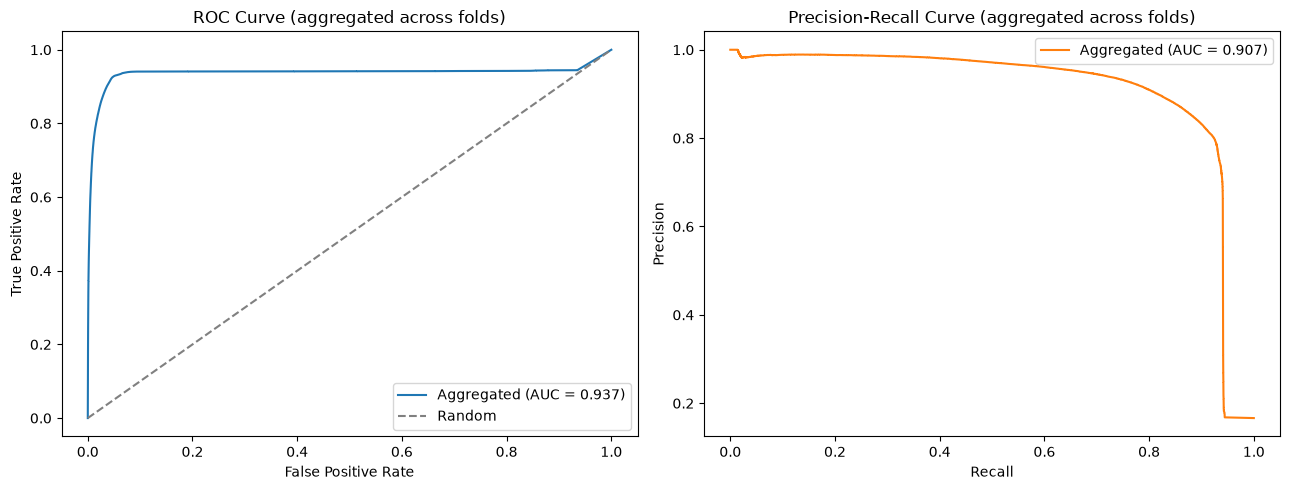

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    mlp_fpr_agg,
    mlp_tpr_agg,
    label=f"Aggregated (AUC = {mlp_auc_roc_agg:.3f})",
    color="tab:blue",
)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (aggregated across folds)")
axes[0].legend()

axes[1].plot(
    mlp_recall_agg,
    mlp_precision_agg,
    label=f"Aggregated (AUC = {mlp_auc_pr_agg:.3f})",
    color="tab:orange",
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (aggregated across folds)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
# Threshold selection via F-beta (beta=2): weights recall higher than precision,
# consistent with the higher cost of a missed insolvency (false negative) vs a
# false alarm (false positive).
mlp_beta = 2

mlp_precision_valid = mlp_precision_agg[:-1]
mlp_recall_valid = mlp_recall_agg[:-1]

mlp_fbeta_scores = (
    (1 + mlp_beta**2)
    * (mlp_precision_valid * mlp_recall_valid)
    / (mlp_beta**2 * mlp_precision_valid + mlp_recall_valid + 1e-10)
)

mlp_best_idx = mlp_fbeta_scores.argmax()
mlp_best_threshold = mlp_pr_thresholds_agg[mlp_best_idx]

print(f"Best threshold (maximizing F{mlp_beta}): {mlp_best_threshold:.4f}")
print(
    f"At that threshold: precision={mlp_precision_valid[mlp_best_idx]:.4f}, "
    f"recall={mlp_recall_valid[mlp_best_idx]:.4f}, "
    f"F{mlp_beta}={mlp_fbeta_scores[mlp_best_idx]:.4f}"
)

Best threshold (maximizing F2): 0.0467
At that threshold: precision=0.7939, recall=0.9264, F2=0.8964


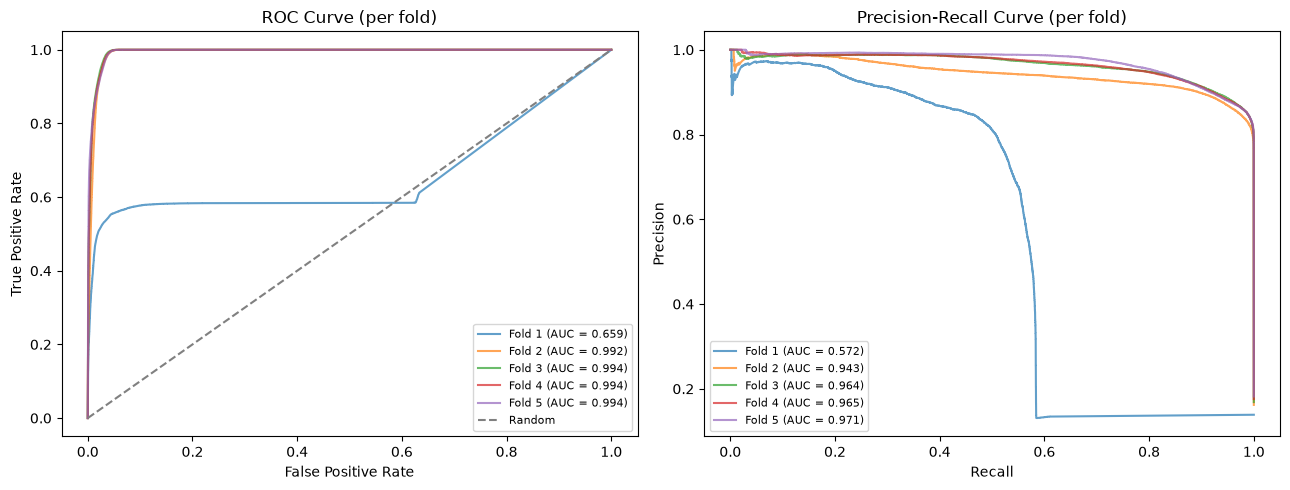

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for fc in mlp_fold_curves:
    axes[0].plot(
        fc["fpr"],
        fc["tpr"],
        alpha=0.7,
        label=f"Fold {fc['fold']} (AUC = {fc['auc_roc']:.3f})",
    )
    axes[1].plot(
        fc["recall"],
        fc["precision"],
        alpha=0.7,
        label=f"Fold {fc['fold']} (AUC = {fc['auc_pr']:.3f})",
    )

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (per fold)")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (per fold)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [22]:
mlp_train_metrics_at_threshold = compute_metrics(
    mlp_all_predictions["y_true"],
    mlp_all_predictions["y_pred_proba"].to_numpy(),
    threshold=mlp_best_threshold,
)
mlp_train_metrics_at_threshold

{'auc_roc': 0.9367094957278382,
 'auc_pr': 0.9074307899983276,
 'precision': 0.7939165610266783,
 'recall': 0.9263503407013461,
 'f1': 0.8550357808509169,
 'true_positives': 111477,
 'false_positives': 28937,
 'true_negatives': 573755,
 'false_negatives': 8863}

## Test metrics

In [23]:
mlp_final_runs = mlflow.search_runs(
    experiment_ids=[mlp_experiment.experiment_id],
    filter_string="tags.mlflow.runName LIKE 'final_model%'",
    order_by=["start_time DESC"],
    max_results=1,
)
mlp_final_run_id = mlp_final_runs.iloc[0]["run_id"]

local_path = mlflow.artifacts.download_artifacts(
    run_id=mlp_final_run_id, artifact_path="predictions"
)
csv_files = [f for f in os.listdir(local_path) if f.endswith(".csv")]
mlp_test_predictions = pd.read_csv(f"{local_path}/{csv_files[0]}")

mlp_test_predictions.shape

(120000, 2)

In [24]:
mlp_fpr_test, mlp_tpr_test, mlp_roc_thresholds_test = roc_curve(
    mlp_test_predictions["y_true"], mlp_test_predictions["y_pred_proba"]
)
mlp_precision_test, mlp_recall_test, mlp_pr_thresholds_test = precision_recall_curve(
    mlp_test_predictions["y_true"], mlp_test_predictions["y_pred_proba"]
)

mlp_auc_roc_test = auc(mlp_fpr_test, mlp_tpr_test)
mlp_auc_pr_test = auc(mlp_recall_test, mlp_precision_test)

print(f"Test AUC-ROC: {mlp_auc_roc_test:.4f}")
print(f"Test AUC-PR:  {mlp_auc_pr_test:.4f}")

Test AUC-ROC: 0.9948
Test AUC-PR:  0.9732


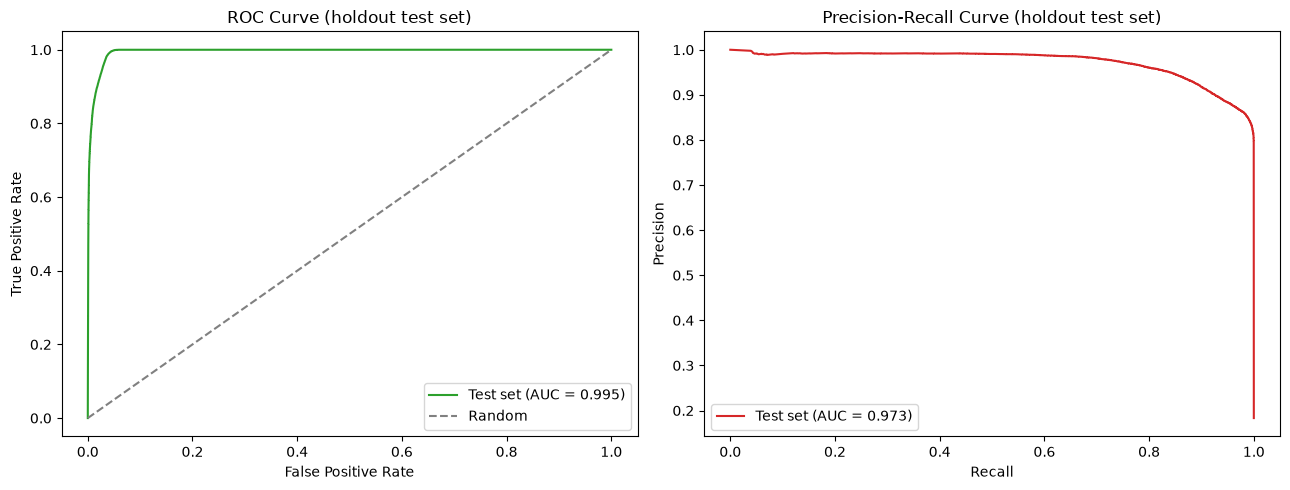

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    mlp_fpr_test,
    mlp_tpr_test,
    label=f"Test set (AUC = {mlp_auc_roc_test:.3f})",
    color="tab:green",
)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (holdout test set)")
axes[0].legend()

axes[1].plot(
    mlp_recall_test,
    mlp_precision_test,
    label=f"Test set (AUC = {mlp_auc_pr_test:.3f})",
    color="tab:red",
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (holdout test set)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
mlp_test_metrics_at_threshold = compute_metrics(
    mlp_test_predictions["y_true"],
    mlp_test_predictions["y_pred_proba"].to_numpy(),
    threshold=mlp_best_threshold,
)
mlp_test_metrics_at_threshold

{'auc_roc': 0.9948361874171916,
 'auc_pr': 0.9731202180693043,
 'precision': 0.7729429545534428,
 'recall': 0.9999545289196071,
 'f1': 0.8719148345657475,
 'true_positives': 21991,
 'false_positives': 6460,
 'true_negatives': 91548,
 'false_negatives': 1}